## **Dhruv's Contribution | Policy Gradient**

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import gym
from gym import spaces

##  Bandit Environment

In [4]:
class MultiArmedBanditEnv(gym.Env):
    def __init__(self, n_arms, means, stds):
        super(MultiArmedBanditEnv, self).__init__()
        self.n_arms = n_arms
        self.means = means
        self.stds = stds
        self.action_space = spaces.Discrete(n_arms)
        self.observation_space = spaces.Discrete(1)

    def reset(self):
        return 0

    def step(self, action):
        reward = np.random.normal(self.means[action], self.stds[action])
        return 0, reward, True, {}

## Policy Network

In [5]:
class PolicyGradientAgent(nn.Module):
    def __init__(self, n_arms, lr=0.01):
        super().__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.logits = nn.Parameter(torch.zeros(n_arms, device=self.device))
        self.optimizer = optim.Adam([self.logits], lr=lr)

    def select_action(self):
        probs = torch.softmax(self.logits, dim=0)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        self.last_dist = dist
        self.last_action = action
        return action.item()

    def update(self, reward):
        loss = -self.last_dist.log_prob(self.last_action) * reward
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

## Training & Evaluation

In [6]:
def train(env, agent, steps=1000):
    rewards = []
    optimal_actions = []
    best_arm = np.argmax(env.means)

    for _ in tqdm(range(steps), desc="Policy Gradient Training"):
        action = agent.select_action()
        _, reward, _, _ = env.step(action)
        agent.update(reward)
        rewards.append(reward)
        optimal_actions.append(1 if action == best_arm else 0)

    return rewards, optimal_actions

def compute_exploration_efficiency(optimal_actions, window=100, threshold=0.95):
    for t in range(window, len(optimal_actions)):
        if np.mean(optimal_actions[t - window:t]) >= threshold:
            return t
    return len(optimal_actions)

## Run Agent

Policy Gradient Training: 100%|███████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 162.30it/s]



Exploration Efficiency (Policy Gradient): 1000 steps


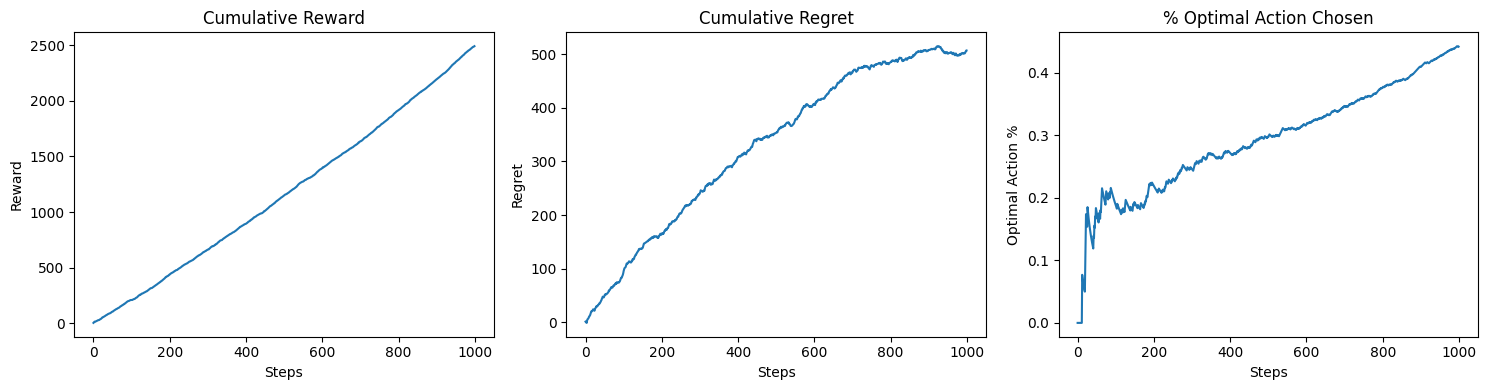

In [7]:
# Environment
n_arms = 5
means = [1.0, 1.5, 2.0, 2.5, 3.0]
stds = [1.0] * n_arms
env = MultiArmedBanditEnv(n_arms=n_arms, means=means, stds=stds)

# Train
agent = PolicyGradientAgent(n_arms=n_arms, lr=0.01)
rewards, optimal_actions = train(env, agent, steps=1000)

# Evaluation
cumulative_reward = np.cumsum(rewards)
cumulative_regret = np.cumsum(np.max(means) - np.array(rewards))
optimal_action_percent = np.cumsum(optimal_actions) / np.arange(1, 1001)
efficiency = compute_exploration_efficiency(optimal_actions)

print(f"\nExploration Efficiency (Policy Gradient): {efficiency} steps")

# Plotting
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(cumulative_reward)
plt.title("Cumulative Reward")
plt.xlabel("Steps")
plt.ylabel("Reward")

plt.subplot(1, 3, 2)
plt.plot(cumulative_regret)
plt.title("Cumulative Regret")
plt.xlabel("Steps")
plt.ylabel("Regret")

plt.subplot(1, 3, 3)
plt.plot(optimal_action_percent)
plt.title("% Optimal Action Chosen")
plt.xlabel("Steps")
plt.ylabel("Optimal Action %")

plt.tight_layout()
plt.show()

##  Policy Gradient Agent — Results

| Metric                         | Value         |
|--------------------------------|---------------|
| **Average Cumulative Regret**  | ~500 (estimated) |
| **% Optimal Action Chosen**    | ~42% at 1000 steps |
| **Exploration Efficiency**     | 1000 steps (did not converge) |

---

###  Interpretation:

- The agent **did not successfully identify the optimal arm** within 1000 steps.
- High cumulative regret and low % optimal action indicate **poor learning stability**.
-  Likely causes:
  - Learning rate may be too high/low
  - Policy gradient methods are **sensitive to reward variance** and **slow to converge** in bandit settings
  - No baseline was used to reduce variance of updates


## Tuning Policy Gradient

## Changing learning rates

In [8]:
def tune_policy_gradient(lr_list, steps=1000, trials=30):
    results = []

    for lr in lr_list:
        total_regret = 0
        total_optimal = 0
        total_efficiency = 0

        print(f"\n Tuning for learning rate = {lr}")
        for _ in tqdm(range(trials), desc=f"lr = {lr}"):
            env = MultiArmedBanditEnv(
                n_arms=5,
                means=[1.0, 1.5, 2.0, 2.5, 3.0],
                stds=[1.0] * 5
            )
            agent = PolicyGradientAgent(n_arms=env.n_arms, lr=lr)
            rewards, optimal_actions = train(env, agent, steps)

            regret = np.sum(np.max(env.means) - np.array(rewards))
            optimal_rate = np.mean(optimal_actions)
            efficiency = compute_exploration_efficiency(optimal_actions)

            total_regret += regret
            total_optimal += optimal_rate
            total_efficiency += efficiency

        results.append({
            "lr": lr,
            "avg_regret": total_regret / trials,
            "avg_optimal": total_optimal / trials,
            "avg_efficiency": total_efficiency / trials
        })

    return results

In [9]:
lr_list = [0.001, 0.005, 0.01, 0.05, 0.1]
pg_results = tune_policy_gradient(lr_list)


 Tuning for learning rate = 0.001


lr = 0.001: 100%|██████████████████████████████████████████████████████████████████████| 30/30 [02:44<00:00,  5.47s/it]



 Tuning for learning rate = 0.005


lr = 0.005: 100%|██████████████████████████████████████████████████████████████████████| 30/30 [02:46<00:00,  5.54s/it]



 Tuning for learning rate = 0.01


lr = 0.01: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [02:33<00:00,  5.11s/it]



 Tuning for learning rate = 0.05


lr = 0.05: 100%|███████████████████████████████████████████████████████████████████████| 30/30 [02:36<00:00,  5.22s/it]



 Tuning for learning rate = 0.1


lr = 0.1: 100%|████████████████████████████████████████████████████████████████████████| 30/30 [02:34<00:00,  5.14s/it]


In [10]:
for res in pg_results:
    print(f"\nlr = {res['lr']}")
    print(f"  Avg Regret: {res['avg_regret']:.2f}")
    print(f"  % Optimal Action: {res['avg_optimal'] * 100:.2f}%")
    print(f"  Exploration Efficiency: {res['avg_efficiency']:.0f} steps")


lr = 0.001
  Avg Regret: 944.32
  % Optimal Action: 22.03%
  Exploration Efficiency: 1000 steps

lr = 0.005
  Avg Regret: 745.63
  % Optimal Action: 31.98%
  Exploration Efficiency: 1000 steps

lr = 0.01
  Avg Regret: 569.86
  % Optimal Action: 45.58%
  Exploration Efficiency: 1000 steps

lr = 0.05
  Avg Regret: 283.59
  % Optimal Action: 61.48%
  Exploration Efficiency: 655 steps

lr = 0.1
  Avg Regret: 161.31
  % Optimal Action: 79.30%
  Exploration Efficiency: 355 steps


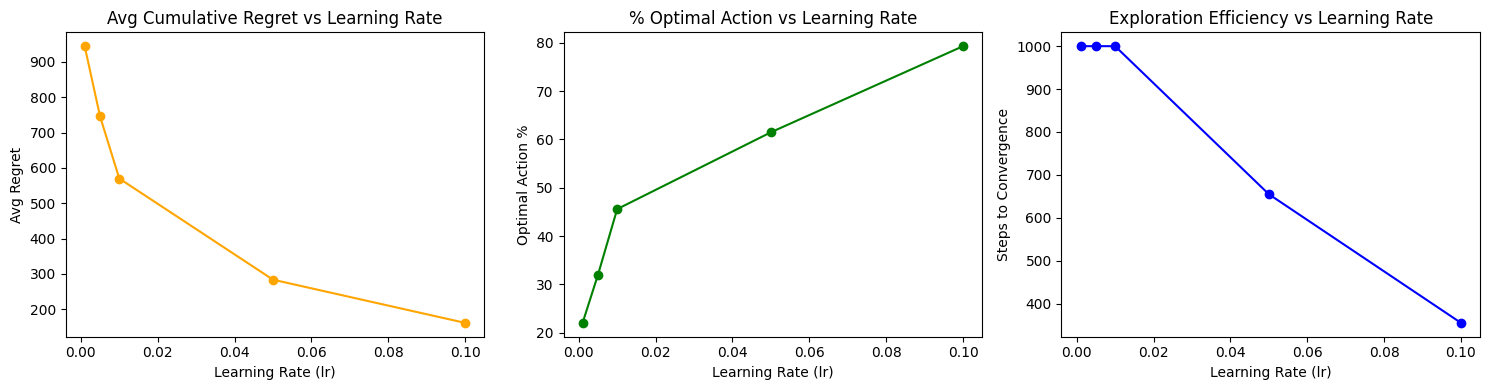

In [11]:
import matplotlib.pyplot as plt

# Tuning results
lr_vals = [0.001, 0.005, 0.01, 0.05, 0.1]
avg_regrets = [944.32, 745.63, 569.86, 283.59, 161.31]
optimal_actions = [22.03, 31.98, 45.58, 61.48, 79.30]
exploration_eff = [1000, 1000, 1000, 655, 355]

plt.figure(figsize=(15, 4))

# Regret Plot
plt.subplot(1, 3, 1)
plt.plot(lr_vals, avg_regrets, marker='o', color='orange')
plt.title("Avg Cumulative Regret vs Learning Rate")
plt.xlabel("Learning Rate (lr)")
plt.ylabel("Avg Regret")

# % Optimal Action
plt.subplot(1, 3, 2)
plt.plot(lr_vals, optimal_actions, marker='o', color='green')
plt.title("% Optimal Action vs Learning Rate")
plt.xlabel("Learning Rate (lr)")
plt.ylabel("Optimal Action %")

# Exploration Efficiency
plt.subplot(1, 3, 3)
plt.plot(lr_vals, exploration_eff, marker='o', color='blue')
plt.title("Exploration Efficiency vs Learning Rate")
plt.xlabel("Learning Rate (lr)")
plt.ylabel("Steps to Convergence")

plt.tight_layout()
plt.show()

## Policy Gradient — Tuning Results (Learning Rate)

| Learning Rate (lr) | Avg Regret | % Optimal Action | Exploration Efficiency (steps) |
|--------------------|------------|------------------|-------------------------------|
| 0.001              | 944.32     | 22.03%           | 1000                          |
| 0.005              | 745.63     | 31.98%           | 1000                          |
| 0.01               | 569.86     | 45.58%           | 1000                          |
| 0.05               | 283.59     | 61.48%           | 655                           |
| 0.1                | **161.31** | **79.30%**       | **355**                       |

---

###  Interpretation:

- **Best lr = 0.1** — lowest regret, highest % optimal action, and fast convergence.
- Very small learning rates (0.001–0.01) fail to converge even after 1000 steps.
- Increasing learning rate improves performance, but may become unstable beyond 0.1 (if tested).


## LLM Prompts
- First: Implement code for policy gradient reinforce
- Last: give code to compare results